## Experiment 2: Individual Reproduction Bias Check


In [1]:
# Import required libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from io import StringIO
import warnings
from scipy.optimize import curve_fit
import pingouin as pg

In [2]:
# Nature-style plotting configuration
import sys
sys.path.insert(0, '../../shared')

import matplotlib.pyplot as plt
import seaborn as sns
from plot_config import (
    set_nature_style, COLORS, TRANSITION_ORDER, TRANSITION_PALETTE,
    DURATION_ORDER, get_transition_palette, despine
)
set_nature_style()

In [3]:
%config InlineBackend.figure_format = 'retina'  

### Strict Control via Minimum Trial Count per TransitionType
#### For stricter control over condition-level variability, we apply a conservative balancing strategy. Specifically, for each subject, we identify the condition with the minimum number of trials among the four TransitionType categories, and downsample all other conditions to match that count.

In [4]:
df = pd.read_pickle("../../data/experiment2/E2.pkl")


---

### Generalized Reproduction Bias Across Participants

To quantify individual-level temporal biases, we computed the mean reproduction bias (`curBias`) for each participant. This yields a subject-level estimate of over- or underestimation in time reproduction.

The resulting participant-wise biases were then summarized at the group level:

* **Mean reproduction bias** reflects the overall direction and magnitude of bias across participants.
* **Standard error (SE)** quantifies variability in bias estimates across the sample.



In [5]:
# reproduction bias for each subject
genRprBias = df.groupby('subID')['curBias'].mean().reset_index()
# Generallized Reproduction Bias


---

### Coefficient of Variation (CV) in Reproduction Responses

To assess intra-individual variability in time reproduction, we computed the **coefficient of variation (CV)** of the reproduced duration (`rpr`) for each participant:

$$
\text{CV} = \frac{\text{SD(rpr)}}{\text{Mean(rpr)}}
$$

This was done after aggregating response count, mean, and standard deviation per subject. The CV provides a normalized index of variability, independent of the absolute magnitude of reproduction.

At the group level, we report:

* **Mean CV** across participants
* **Standard error of CV**
* **One-sample t-test** comparing individual CVs against zero (baseline reference)

This analysis quantifies response consistency and allows inferences about trial-level variability across the sample.


In [6]:
# reproduction CV（Coefficient of Variation）
RprCV = df.groupby('subID').agg({'rpr': ['count', 'mean', 'std']}).reset_index()
RprCV.columns = ['subID', 'count', 'mean', 'std']
RprCV['cv'] = RprCV['std'] / RprCV['mean']
# overall CV
# t-test



Participants exhibited consistent intra-individual variability in time reproduction, as indexed by the coefficient of variation (mean CV = 0.213, SE = 0.011). A one-sample t-test confirmed that the CV was significantly greater than zero (t(20) = 19.81, p < .001, Cohen's d = 4.32), indicating reliable fluctuations in temporal precision across trials.
After this, we calculated the mean CV for each sampling points, 0.8, 1.0, 1.2, 1.4, 1.6.

In [7]:
mCVPar = df.groupby(['subID', 'curDur']).agg({'rpr': ['count', 'mean', 'std']}).reset_index()
mCVPar.columns = ['subID', 'curDur', 'count', 'mean', 'std']
mCVPar['cv'] = mCVPar['std'] / mCVPar['mean']


mCVAll = mCVPar.groupby('curDur').agg({'cv': ['count', 'mean', 'sem']
}).reset_index()
mCVAll.columns = ['curDur', 'count', 'mCV', 'seCV']



We observed a systematic decrease in the coefficient of variation (CV) of reproduction responses as the target duration increased from 0.8 to 1.6 seconds. This pattern, with mean CVs ranging from 0.174 (0.8s) to 0.125 (1.6s), reflects higher relative variability for shorter intervals, consistent with Weber’s law in temporal perception

---

### 1. Group-Level Variability: SD vs. Target Duration

To quantify **absolute reproduction variability** across durations, we computed the standard deviation (SD) of reproduced durations (`rpr`) for each target duration (`curDur`) across all participants. A line plot with error bars (±SEM) illustrates how SD changes as a function of interval length.

* **Observation**: SD increases with `curDur`, indicating larger absolute errors at longer durations.
* **Interpretation**: This pattern suggests scalar variability, consistent with time perception theories such as scalar timing and Weber’s law.



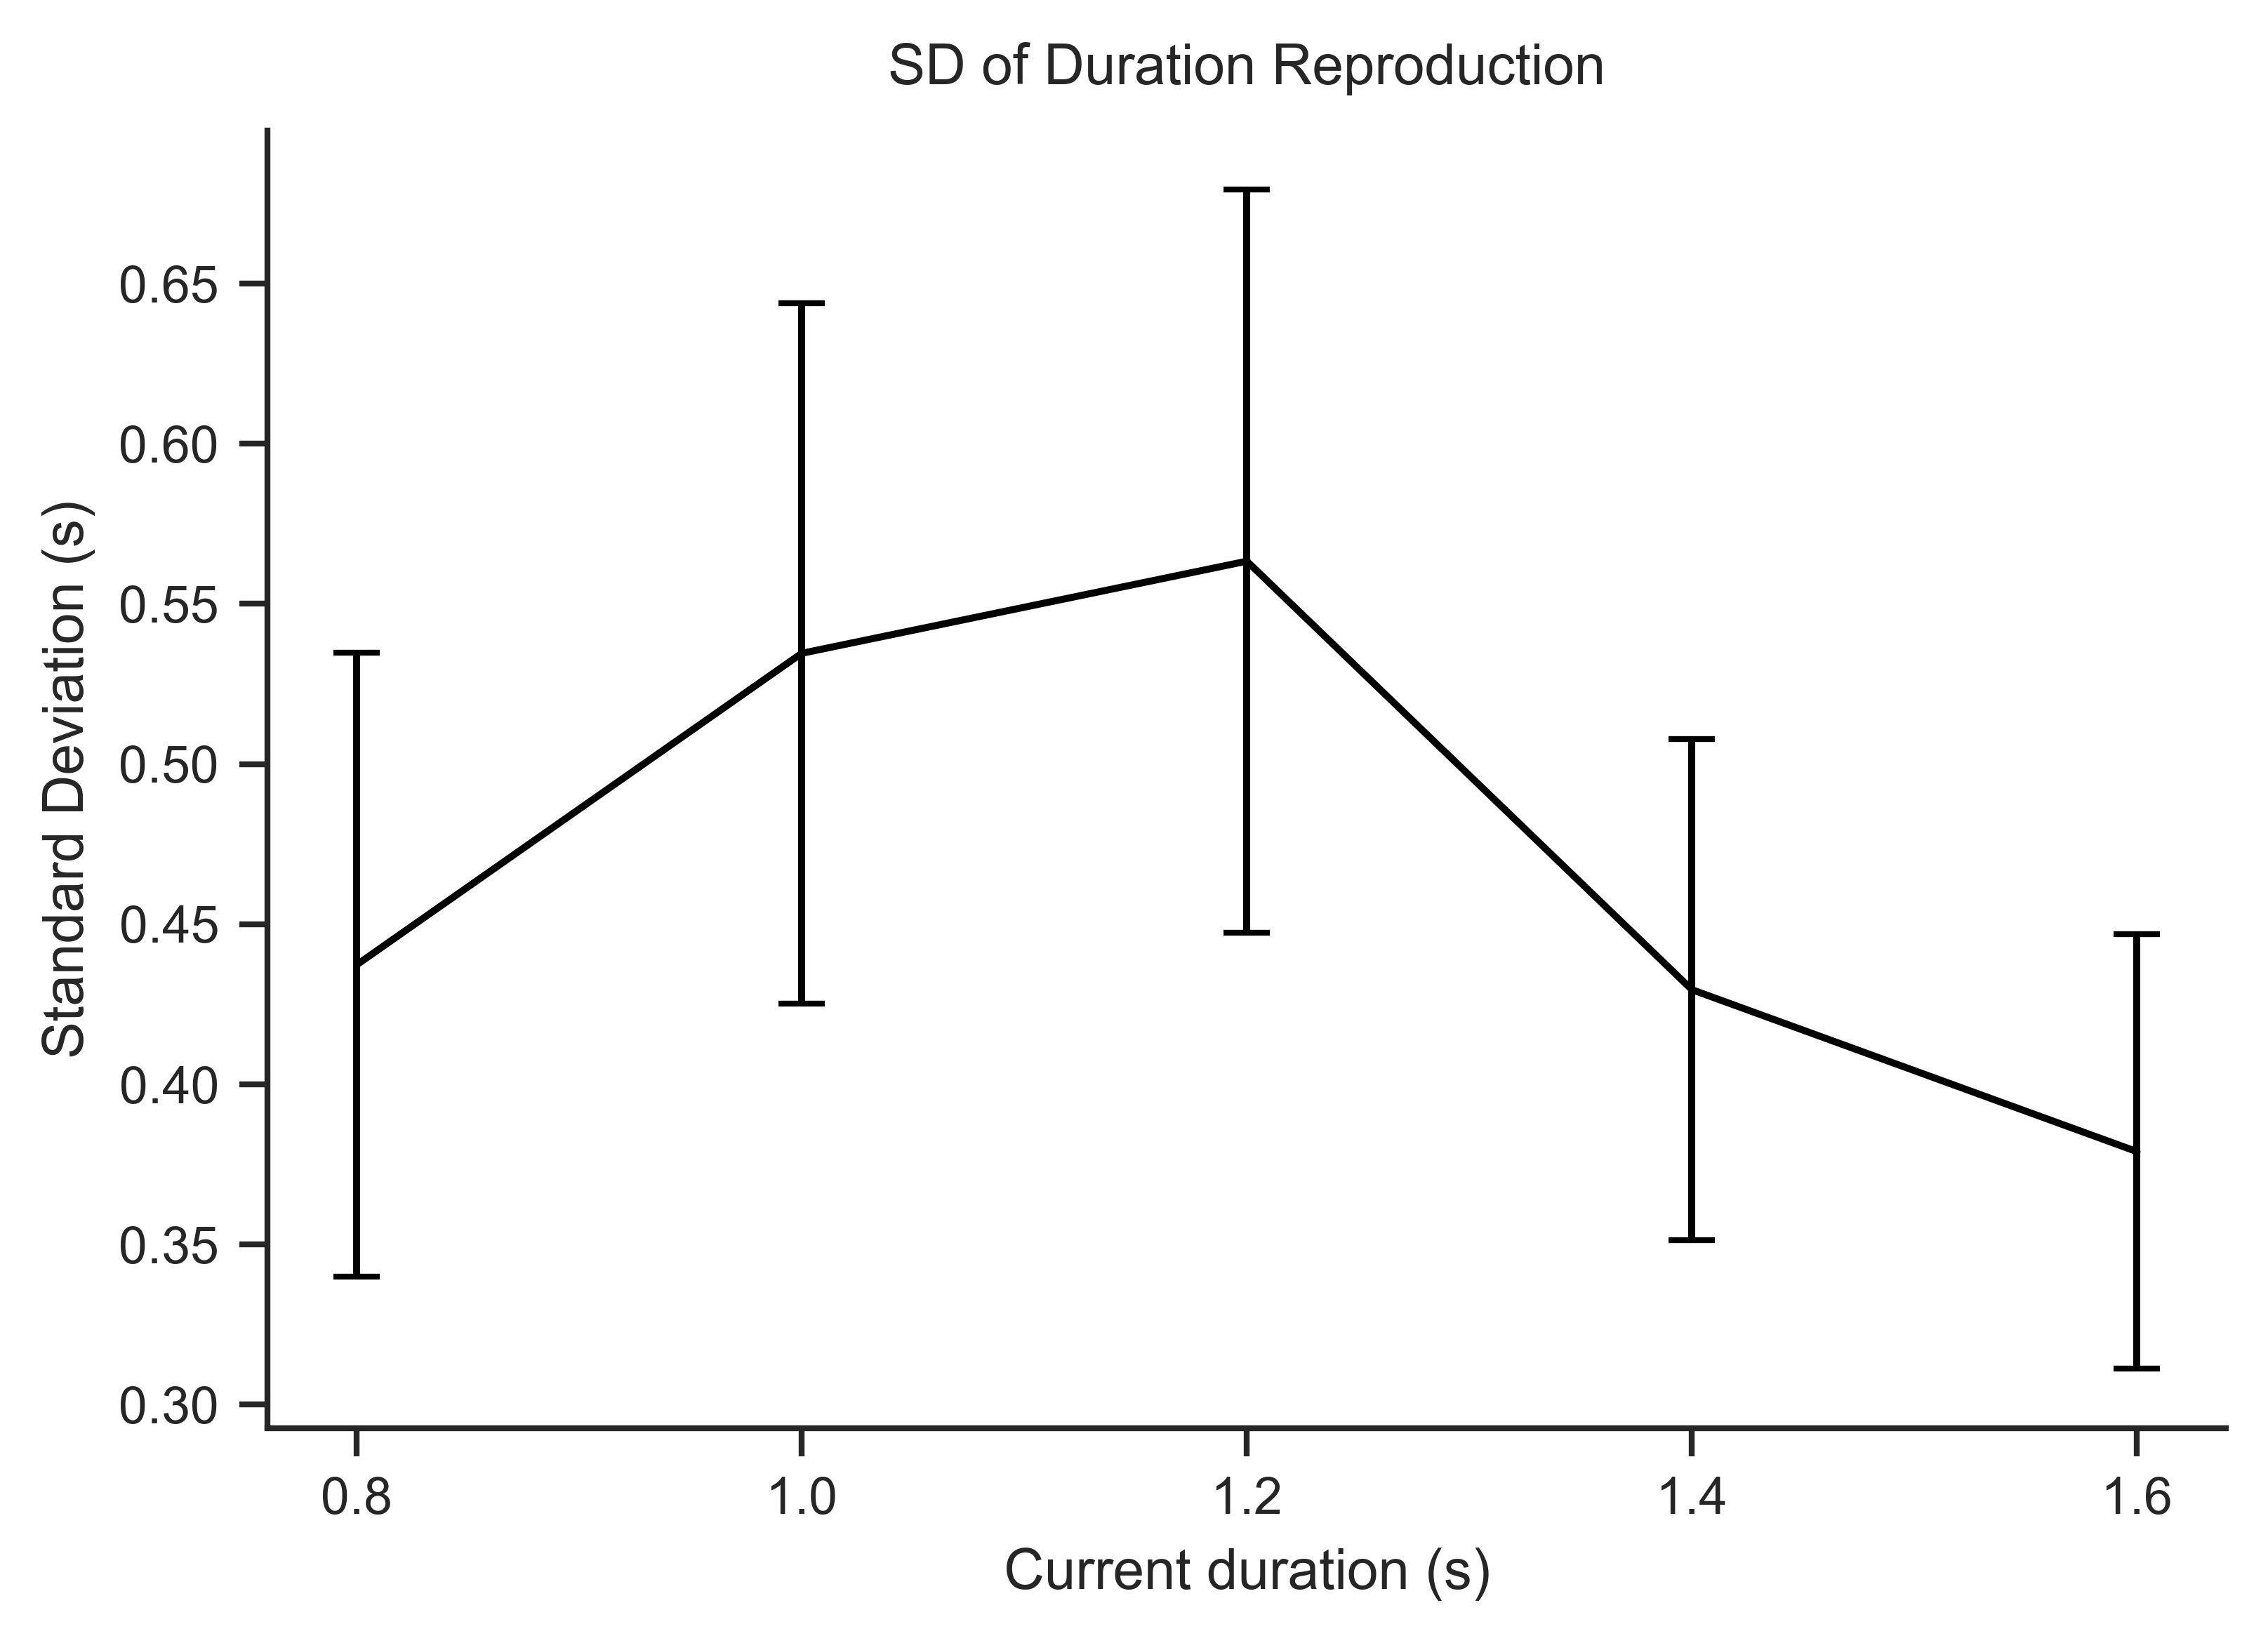

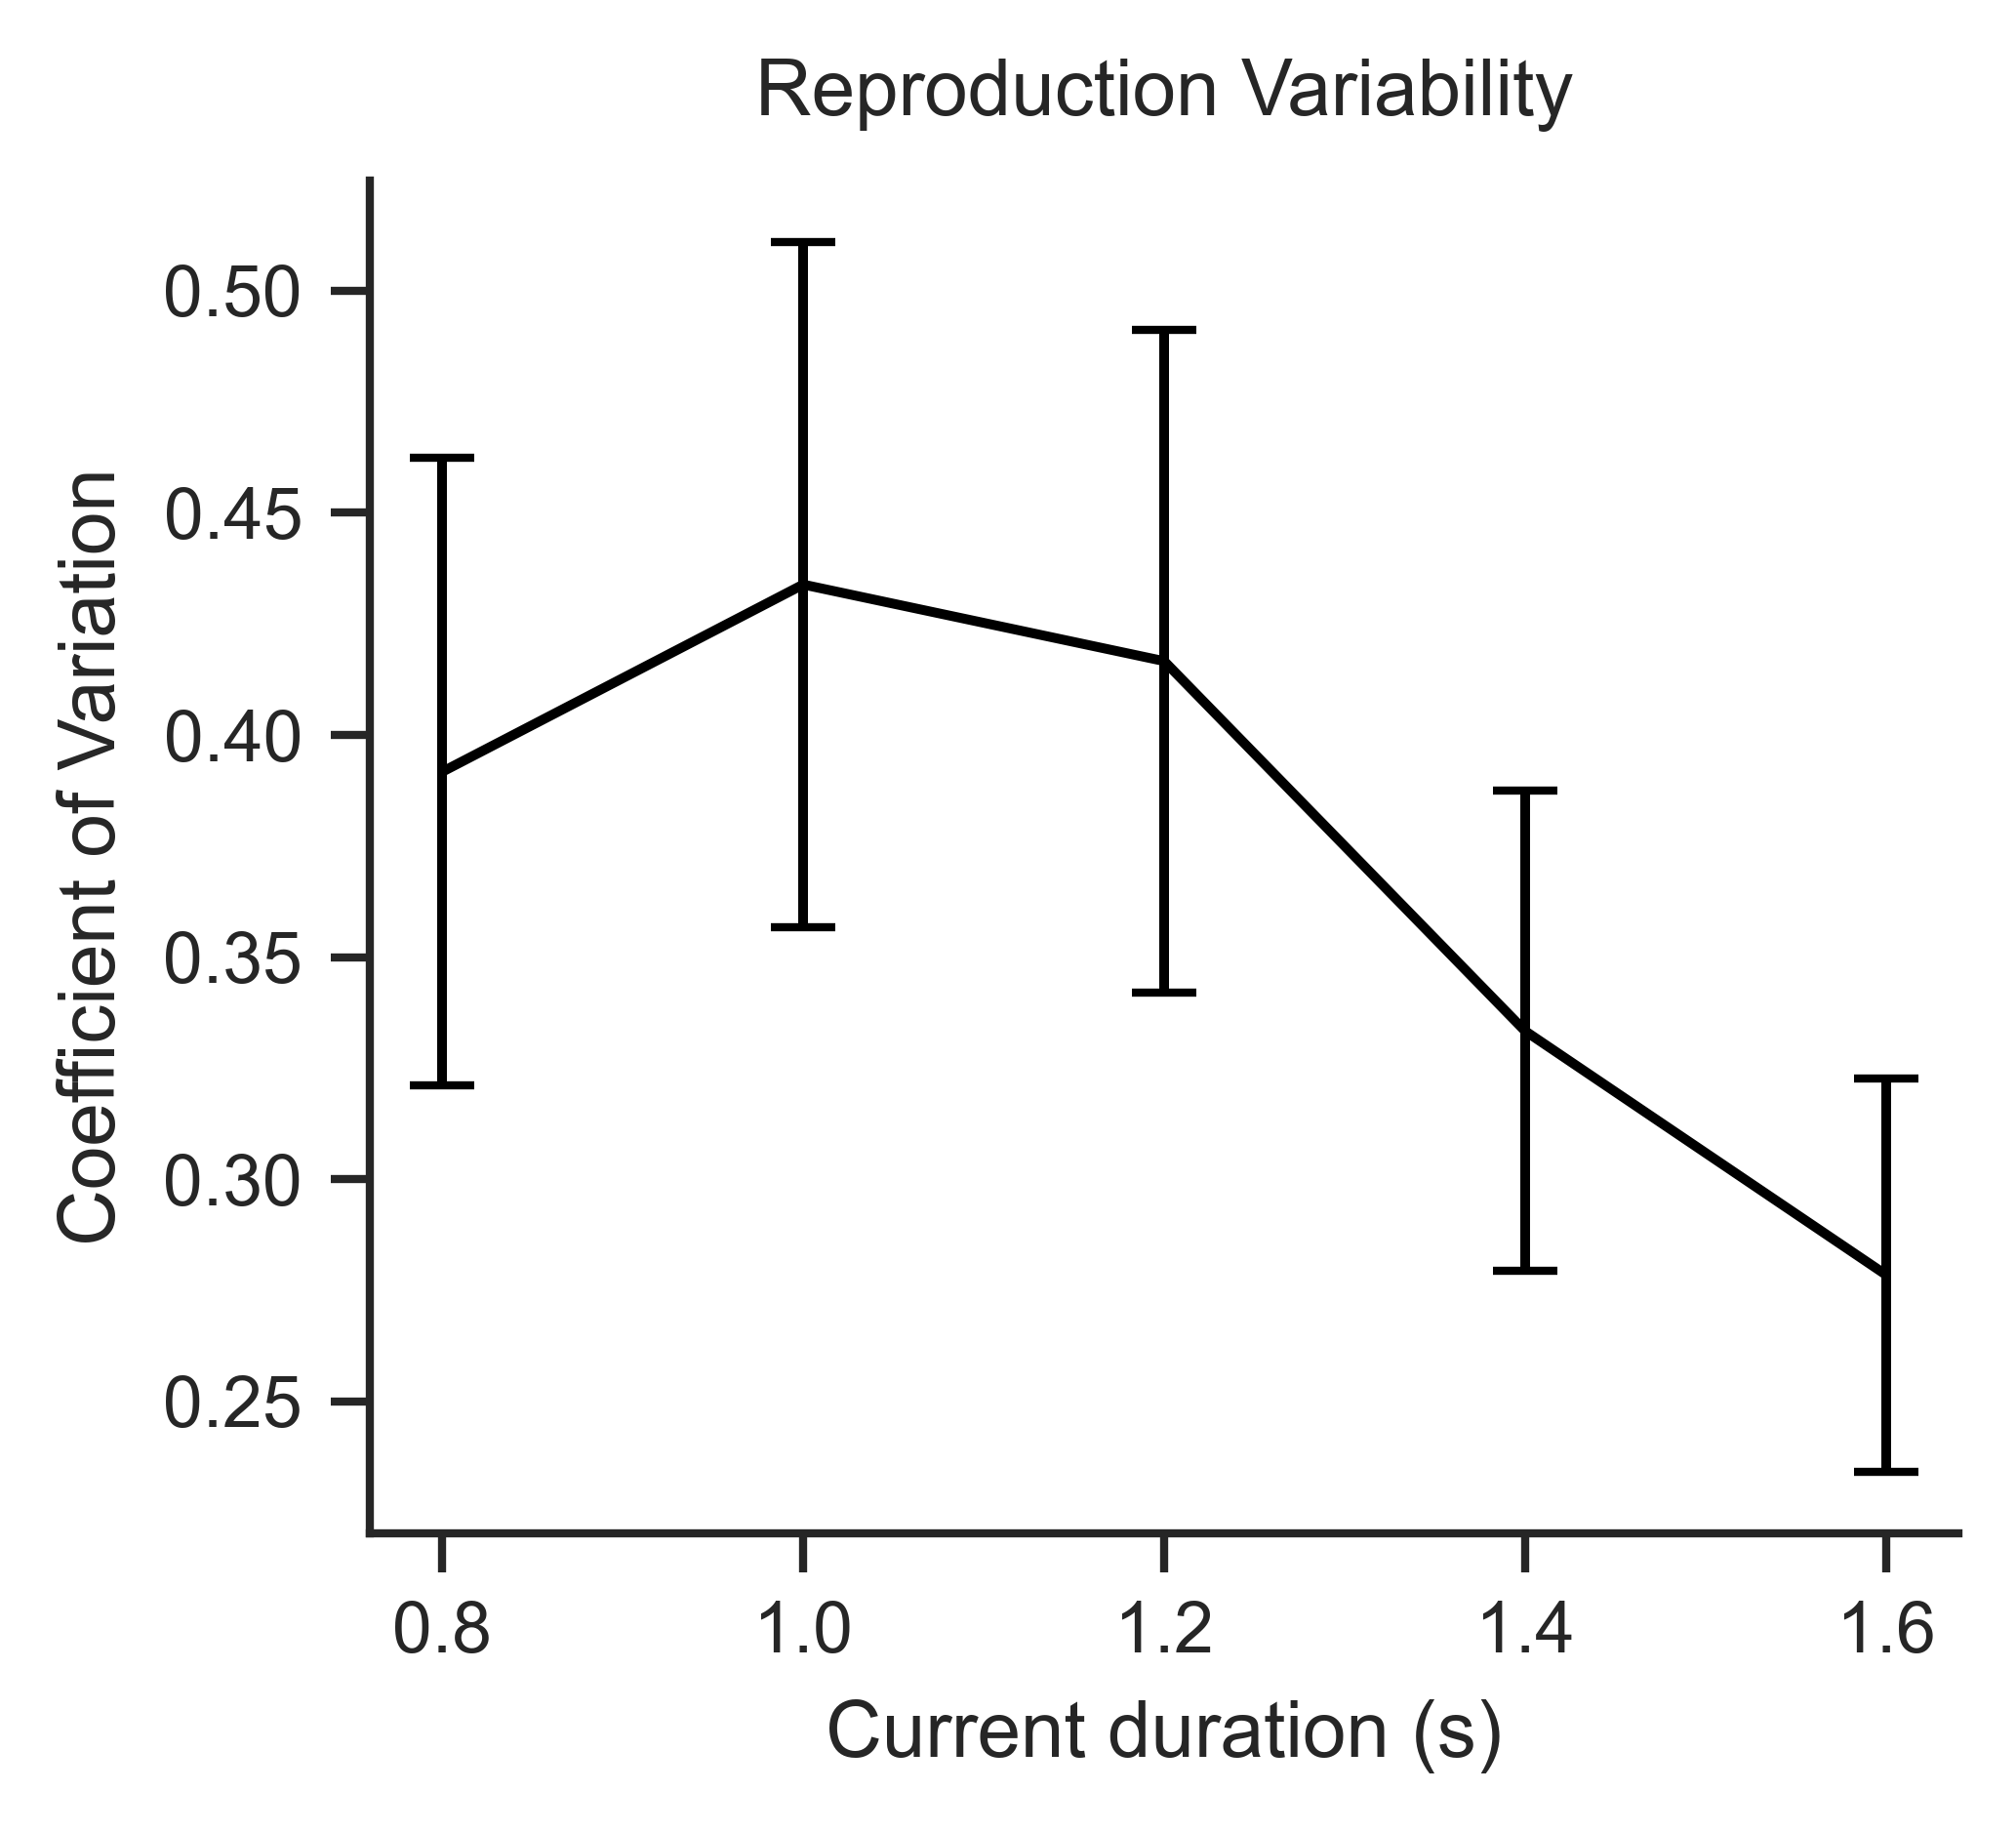

In [8]:
# plot SD vs current duration
mSDAll = mCVPar.groupby('curDur').agg({'std': ['count', 'mean', 'sem']}).reset_index()
mSDAll.columns = ['curDur', 'count', 'mSD', 'seSD']

fig, ax = plt.subplots(figsize=(6, 4))
plt.errorbar(x='curDur', y='mSD', yerr='seSD', data=mSDAll, color='black', capsize=4)
plt.xticks(mSDAll['curDur'])
plt.xlabel('Current duration (s)')
plt.ylabel('Standard Deviation (s)')
plt.title('SD of Duration Reproduction')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plot CV vs current duration
fig, ax = plt.subplots()
plt.errorbar(x='curDur', y='mCV', yerr='seCV', data=mCVAll, color='black', capsize=4)
plt.xticks(mCVAll['curDur'])
plt.xlabel('Current duration (s)')
plt.ylabel('Coefficient of Variation')
plt.title('Reproduction Variability')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

---

### 2. Within-Subject CV Trend: CV across Durations (Per Participant)

To explore **individual variability scaling**, we visualized the **coefficient of variation (CV)** across different durations (`curDur`) for each subject. 



In [9]:
g = sns.relplot(
    data = mCVPar,kind = 'line', x = 'curDur',y = 'cv', col = 'subID', col_wrap = 4,marker = 'o',
    facet_kws={'sharey': False}, 
    height = 4,
    aspect = 1.2
)

g.set_axis_labels("Current Duration (s)", "CV")
g.set_titles("{col_name}") 
plt.subplots_adjust(top=0.85) 
g.fig.suptitle('CV across durations for each subject', fontsize=16)
plt.show()

---

### 3. Within-Subject SD Trend: SD across Durations (Per Participant)

In addition to CV, we computed the **standard deviation of reproduction (SD)** per `curDur` and `subID` to track **absolute variability trends** per participant. Using Seaborn’s `relplot`, we visualized how SD scales with duration within each individual.





In [10]:
mSDPar = df.groupby(['subID', 'curDur']).agg(count=('rpr', 'count'), std=('rpr', 'std')).reset_index()
mSDPar['seSD'] = mSDPar['std'] / np.sqrt(mSDPar['count'])

g = sns.relplot( data=mSDPar, kind='line', x='curDur', y='std', col='subID',
    col_wrap=4,  height=4, aspect=1.2)

g.set_axis_labels("Current Duration (s)", "Standard Deviation (SD)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.8)
g.fig.suptitle("Standard Deviation across Durations for Each Subject", fontsize=16)
plt.show()